# Assignment 1 by: Muzamil Mohammed

In [7]:
# Student details
student_name = "Muzamil Mohammed"
student_id = "s1234567"

print("Student Name:", student_name)
print("Student ID:", student_id)

Student Name: Muzamil Mohammed
Student ID: s1234567


# Task 1: Data Preparation


In [8]:
# Import the libraries needed for this assignment
import pandas as pd
import matplotlib.pyplot as plt

# Load the Airbnb dataset
df = pd.read_csv("A1data.xls", dtype={"host_id": "string"})

print("Dataset size:", df.shape)
display(df.head())

Dataset size: (10042, 15)


,id,name,host_id,host_name,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,availability_365,number_of_reviews_ltm
0,43429,Tranquil Javanese Studio and Pond!,189684,Allan,Monash,-37.899830,145.115790,Entire home/apt,165,2,280,14/05/2026,1.48,278,11
1,44699,"15 yearsHosting (4.8), 8 CITY TRAMS, GymPoolTe...",189245,Christine,Port Phillip,-37.831557,144.970644,Private room,215,1,67,17/05/2026,0.35,169,1
2,51592,Central City Warehouse Apartment,190879,Michelle,Melbourne,-37.812660,144.963130,Entire home/apt,294,2,537,07/06/2026,2.88,208,39
3,74324,Eclectic luxury living (long term stays welcome),390761,Matthew,Yarra,-37.804150,144.978030,Entire home/apt,435,2,107,30/05/2026,0.79,288,21
4,86369,"Sunny 1950s Apartment, St Kilda East \nLonger ...",246509,Fiona,Glen Eira,-37.870789,145.007034,Entire home/apt,229,21,14,17/12/2022,0.13,73,0


In [9]:
# Check the structure of the dataset
df.info()

print("\nMissing values:")
print(df.isnull().sum())

print("\nNumber of duplicate rows:")
print(df.duplicated().sum())

print("\nRoom type values:")
print(df["room_type"].value_counts(dropna=False))

<class 'pandas.DataFrame'>
RangeIndex: 10042 entries, 0 to 10041
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     10042 non-null  int64  
 1   name                   10042 non-null  str    
 2   host_id                10042 non-null  string 
 3   host_name              10042 non-null  str    
 4   neighbourhood          10042 non-null  str    
 5   latitude               10042 non-null  float64
 6   longitude              10042 non-null  float64
 7   room_type              10042 non-null  str    
 8   price                  10042 non-null  int64  
 9   minimum_nights         10042 non-null  int64  
 10  number_of_reviews      10042 non-null  int64  
 11  last_review            10042 non-null  str    
 12  reviews_per_month      10042 non-null  float64
 13  availability_365       10042 non-null  int64  
 14  number_of_reviews_ltm  10042 non-null  int64  
dtypes: float64(3)

In [10]:
# Check important numerical ranges
print("Price range:", df["price"].min(), "to", df["price"].max())
print("Minimum nights range:", df["minimum_nights"].min(), "to", df["minimum_nights"].max())
print("Availability range:", df["availability_365"].min(), "to", df["availability_365"].max())
print("Latitude range:", df["latitude"].min(), "to", df["latitude"].max())
print("Longitude range:", df["longitude"].min(), "to", df["longitude"].max())

# Check invalid availability values
invalid_availability = df[~df["availability_365"].between(0, 365)]

print("\nInvalid availability values:")
display(invalid_availability[
    ["id", "neighbourhood", "availability_365"]
])

# Melbourne latitudes should be negative
invalid_latitude = df[df["latitude"] > 0]

print("\nSuspicious latitude values:")
display(invalid_latitude[
    ["id", "neighbourhood", "latitude", "longitude"]
])

Price range: 100 to 1000
Minimum nights range: 1 to 90
Availability range: 0 to 365
Latitude range: -38.22569 to -37.4403857
Longitude range: 144.51811 to 145.85282

Invalid availability values:


,id,neighbourhood,availability_365



Suspicious latitude values:


,id,neighbourhood,latitude,longitude


In [11]:
# Check room type categories
print("Unique room types:")
print(df["room_type"].unique())

# Check host IDs written in scientific notation
scientific_host_ids = df[
    df["host_id"].str.contains("e", case=False, na=False)
]

print("\nHost IDs in scientific notation:")
display(scientific_host_ids[["id", "host_id", "host_name"]])

Unique room types:
<StringArray>
['Entire home/apt', 'Private room', 'Hotel room', 'Shared room']
Length: 4, dtype: str

Host IDs in scientific notation:


,id,host_id,host_name


In [12]:
# Remove exact duplicate rows
df = df.drop_duplicates().copy()

# Correct inconsistent room type names
df["room_type"] = df["room_type"].replace({
    "Entire home/apartment": "Entire home/apt",
    "Private rooms": "Private room"
})

# Fill missing minimum_nights with the median
median_nights = df["minimum_nights"].median()
df["minimum_nights"] = df["minimum_nights"].fillna(median_nights)

# Fill missing number_of_reviews with the median
median_reviews = df["number_of_reviews"].median()
df["number_of_reviews"] = df["number_of_reviews"].fillna(median_reviews)

# Convert these columns back to whole numbers
df["minimum_nights"] = df["minimum_nights"].astype(int)
df["number_of_reviews"] = df["number_of_reviews"].astype(int)

print("Duplicates remaining:", df.duplicated().sum())
print("Missing values remaining:", df.isnull().sum().sum())

Duplicates remaining: 0
Missing values remaining: 0


In [13]:
# Correct latitude values with the wrong positive sign
df.loc[df["latitude"] > 0, "latitude"] = (
    -df.loc[df["latitude"] > 0, "latitude"]
)

# Find valid availability values
valid_availability = df["availability_365"].between(0, 365)

# Calculate median using only valid values
availability_median = int(
    df.loc[valid_availability, "availability_365"].median()
)

# Replace invalid availability values with the valid median
df.loc[
    ~valid_availability,
    "availability_365"
] = availability_median

df["availability_365"] = df["availability_365"].astype(int)

print("Invalid latitude values remaining:",
      (df["latitude"] > 0).sum())

print("Invalid availability values remaining:",
      (~df["availability_365"].between(0, 365)).sum())

Invalid latitude values remaining: 0
Invalid availability values remaining: 0


In [14]:
# Convert host IDs written in scientific notation to normal text
def clean_host_id(value):
    value = str(value)
    
    if "e" in value.lower():
        return f"{float(value):.0f}"
    
    return value

df["host_id"] = df["host_id"].apply(clean_host_id)

print("Scientific notation host IDs remaining:",
      df["host_id"].str.contains("e", case=False, na=False).sum())

Scientific notation host IDs remaining: 0


In [15]:
# Function to repair text encoding problems
def fix_text(text):
    if not isinstance(text, str):
        return text
    
    try:
        return text.encode("mac_roman").decode("utf-8")
    except (UnicodeEncodeError, UnicodeDecodeError):
        return text

# Apply the correction to text columns containing encoding issues
df["name"] = df["name"].apply(fix_text)
df["host_name"] = df["host_name"].apply(fix_text)

display(df[["name", "host_name"]].head())

,name,host_name
0,Tranquil Javanese Studio and Pond!,Allan
1,"15 yearsHosting (4.8), 8 CITY TRAMS, GymPoolTe...",Christine
2,Central City Warehouse Apartment,Michelle
3,Eclectic luxury living (long term stays welcome),Matthew
4,"Sunny 1950s Apartment, St Kilda East \nLonger ...",Fiona


In [16]:
# Final checks after cleaning
print("Final dataset size:", df.shape)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nRoom types:")
print(df["room_type"].value_counts())

print("\nInvalid availability values:",
      (~df["availability_365"].between(0, 365)).sum())

print("Positive latitude values:",
      (df["latitude"] > 0).sum())

Final dataset size: (10042, 15)

Missing values:


id                       0
name                     0
host_id                  0
host_name                0
neighbourhood            0
latitude                 0
longitude                0
room_type                0
price                    0
minimum_nights           0
number_of_reviews        0
last_review              0
reviews_per_month        0
availability_365         0
number_of_reviews_ltm    0
dtype: int64

Duplicate rows: 0

Room types:
room_type
Entire home/apt    9088
Private room        934
Hotel room           16
Shared room           4
Name: count, dtype: int64

Invalid availability values: 0
Positive latitude values: 0


In [17]:
# Save the cleaned dataset using the required filename
cleaned_file = f"{student_id}-cleaned-A1data.csv"

df.to_csv(cleaned_file, index=False)

print("Cleaned dataset saved as:", cleaned_file)

Cleaned dataset saved as: s1234567-cleaned-A1data.csv


# Task 2: Data Exploration

## Task 2.1 

In [18]:
# Load the cleaned dataset for Task 2
cleaned_df = pd.read_csv(
    f"{student_id}-cleaned-A1data.csv",
    dtype={"host_id": "string"}
)

print("Cleaned dataset loaded:", cleaned_df.shape)

Cleaned dataset loaded: (10042, 15)


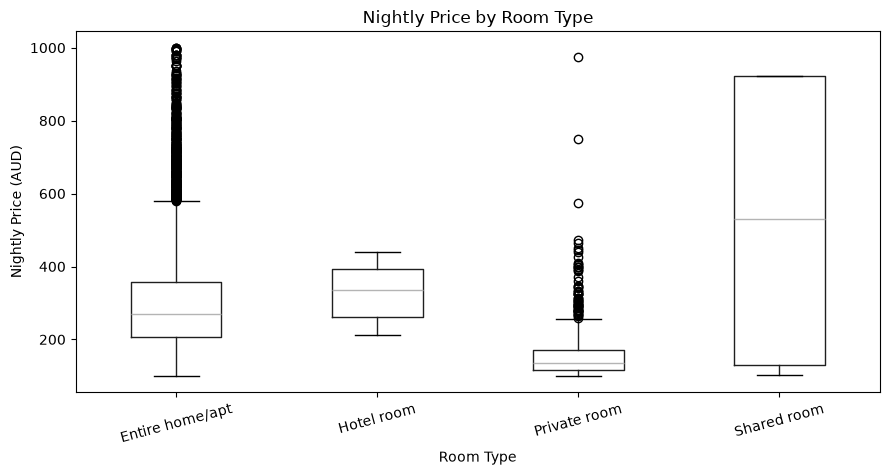

Median nightly price by room type:
room_type
Shared room        530.0
Hotel room         334.5
Entire home/apt    270.0
Private room       135.0
Name: price, dtype: float64


In [19]:
# Create side-by-side boxplots of price by room type
cleaned_df.boxplot(
    column="price",
    by="room_type",
    figsize=(9, 5),
    grid=False
)

plt.suptitle("")
plt.title("Nightly Price by Room Type")
plt.xlabel("Room Type")
plt.ylabel("Nightly Price (AUD)")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# Calculate median price for each room type
median_prices = (
    cleaned_df.groupby("room_type")["price"]
    .median()
    .sort_values(ascending=False)
)

print("Median nightly price by room type:")
print(median_prices)

## Task 2.2 

In [20]:
# Calculate mean nightly price for each neighbourhood
mean_price = (
    cleaned_df.groupby("neighbourhood")["price"]
    .mean()
    .sort_values(ascending=False)
)

# Display the five neighbourhoods with the highest mean price
top_five = mean_price.head(5).round(2)

print("Top five neighbourhoods by mean nightly price:")
display(top_five.to_frame(name="Mean Price (AUD)"))

Top five neighbourhoods by mean nightly price:


,Mean Price (AUD)
neighbourhood,
Yarra Ranges,376.49
Casey,320.82
Bayside,319.62
Manningham,319.46
Nillumbik,315.12


## Task 2.3 

In [21]:
# Keep only Entire home/apt listings
entire_home = cleaned_df[
    cleaned_df["room_type"] == "Entire home/apt"
].copy()

# Find the three neighbourhoods with the most listings
top_three = entire_home["neighbourhood"].value_counts().head(3)

print("Top three neighbourhoods for Entire home/apt:")
print(top_three)

Top three neighbourhoods for Entire home/apt:
neighbourhood
Melbourne       3750
Port Phillip     889
Yarra Ranges     681
Name: count, dtype: int64


In [22]:
# Keep listings from the top three neighbourhoods
top_three_data = entire_home[
    entire_home["neighbourhood"].isin(top_three.index)
]

# Compare nightly prices using several statistical measures
price_statistics = (
    top_three_data.groupby("neighbourhood")["price"]
    .agg(["mean", "median", "std", "min", "max"])
    .round(2)
)

# Keep the same order as the top-three listing counts
price_statistics = price_statistics.loc[top_three.index]

display(price_statistics)

,mean,median,std,min,max
neighbourhood,,,,,
Melbourne,291.25,265.5,122.22,103,997
Port Phillip,285.34,247.0,139.13,101,951
Yarra Ranges,387.15,346.0,176.11,109,992


## Task 2.4

In [23]:
# Count listings in each neighbourhood
neighbourhood_counts = cleaned_df["neighbourhood"].value_counts()

highest_neighbourhood = neighbourhood_counts.idxmax()
highest_count = neighbourhood_counts.max()

print("Neighbourhood with the highest concentration:",
      highest_neighbourhood)

print("Number of listings:", highest_count)

Neighbourhood with the highest concentration: Melbourne
Number of listings: 3981


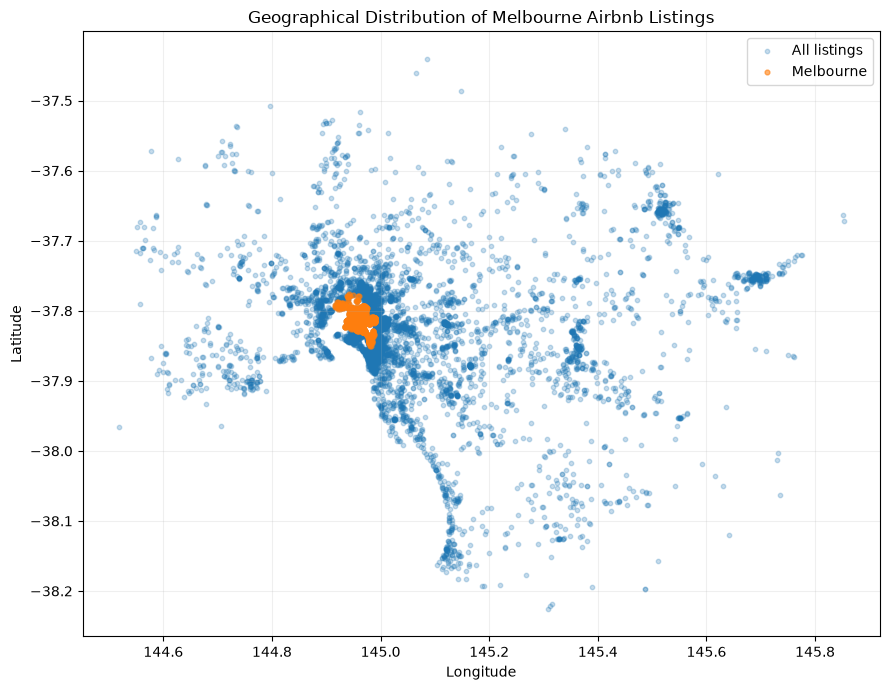

In [24]:
# Listings belonging to the highest concentration neighbourhood
highest_area = cleaned_df[
    cleaned_df["neighbourhood"] == highest_neighbourhood
]

plt.figure(figsize=(9, 7))

# Plot all Airbnb listings
plt.scatter(
    cleaned_df["longitude"],
    cleaned_df["latitude"],
    s=10,
    alpha=0.25,
    label="All listings"
)

# Highlight listings in the highest concentration neighbourhood
plt.scatter(
    highest_area["longitude"],
    highest_area["latitude"],
    s=12,
    alpha=0.6,
    label=highest_neighbourhood
)

plt.title("Geographical Distribution of Melbourne Airbnb Listings")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()